In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import scipy.stats as stats

In [9]:
train_data = pd.read_csv("C:/test1/train.csv")
test_data = pd.read_csv("C:/test1/test.csv")

In [11]:
print('训练集维度:', train_data.shape)
print('测试集维度:', test_data.shape)

训练集维度: (15289, 18)
测试集维度: (10194, 17)


In [12]:
print('-'*50)
print('训练集信息:')
print(train_data.info())

--------------------------------------------------
训练集信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15289 entries, 0 to 15288
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15289 non-null  int64  
 1   clonesize             15289 non-null  float64
 2   honeybee              15289 non-null  float64
 3   bumbles               15289 non-null  float64
 4   andrena               15289 non-null  float64
 5   osmia                 15289 non-null  float64
 6   MaxOfUpperTRange      15289 non-null  float64
 7   MinOfUpperTRange      15289 non-null  float64
 8   AverageOfUpperTRange  15289 non-null  float64
 9   MaxOfLowerTRange      15289 non-null  float64
 10  MinOfLowerTRange      15289 non-null  float64
 11  AverageOfLowerTRange  15289 non-null  float64
 12  RainingDays           15289 non-null  float64
 13  AverageRainingDays    15289 non-null  float64
 14  fruitset    

In [13]:
print('-'*50)
print('训练集缺失值:')
print(train_data.isna().sum())
print('训练集重复值:', train_data.duplicated().sum())

--------------------------------------------------
训练集缺失值:
id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
yield                   0
dtype: int64
训练集重复值: 0


In [14]:
train_data.drop(['id'], axis=1, inplace=True)
test_data.drop(['id'], axis=1, inplace=True)

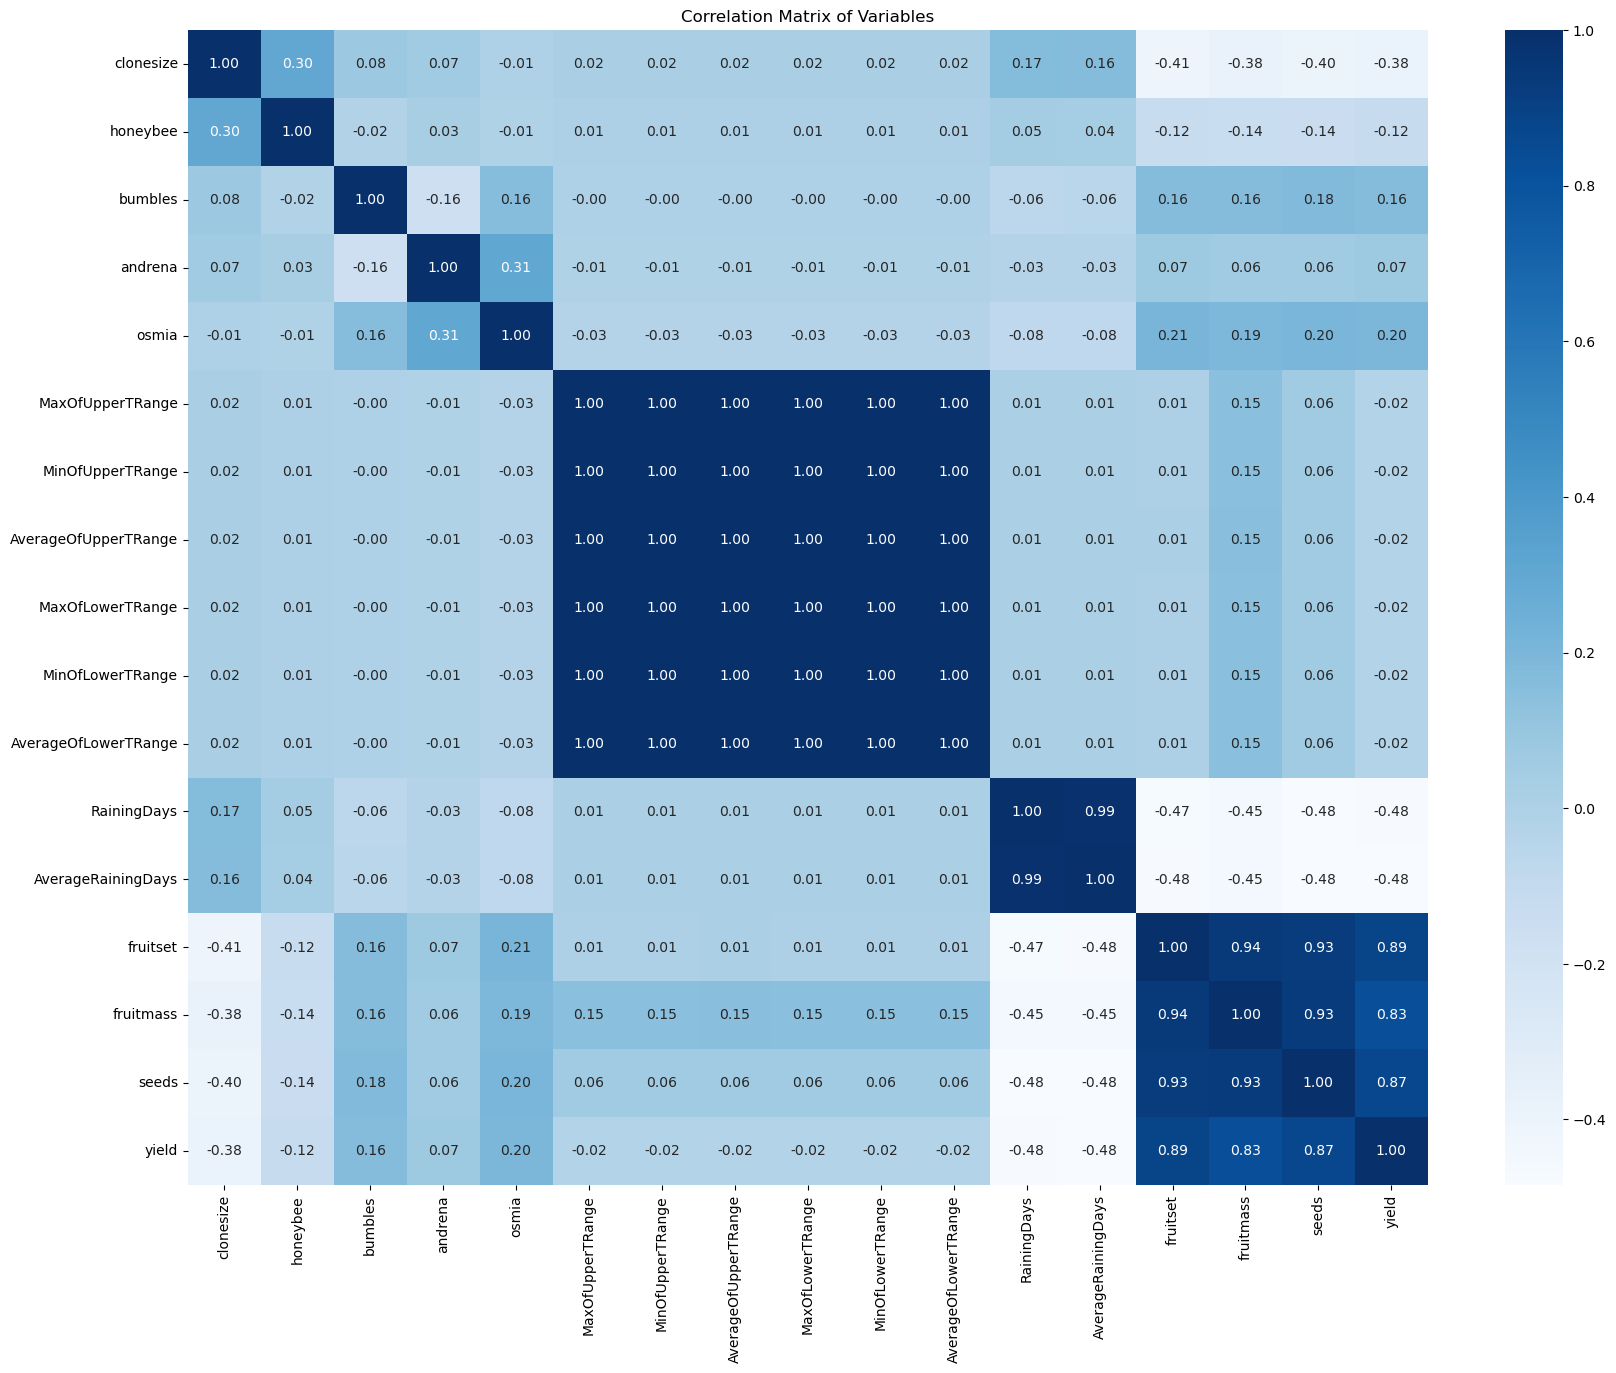

In [15]:
correlation_matrix = train_data.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix of Variables")
plt.show()

In [17]:
x_cluster = train_data.copy()
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_cluster)

In [19]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    # 修复：添加 n_init='auto'
    kmeans = KMeans(n_clusters=k, random_state=10, n_init='auto').fit(x_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x_scaled, kmeans.labels_))

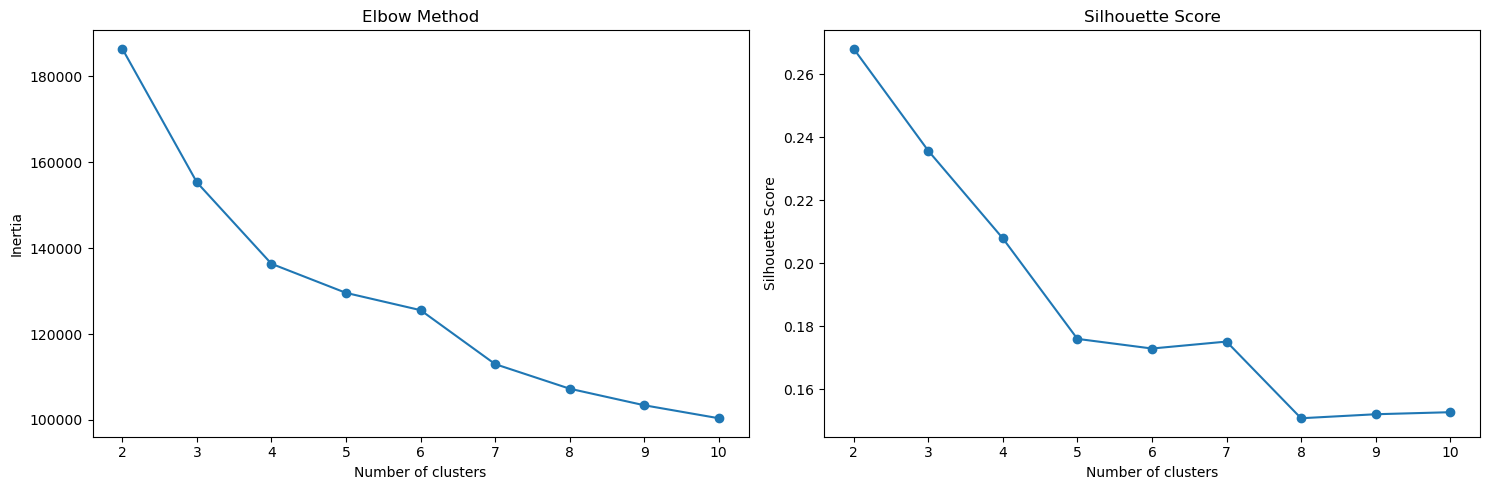

In [22]:
plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.tight_layout()
plt.show()

In [23]:
kmeans_final = KMeans(n_clusters=4, random_state=15, n_init='auto')
kmeans_final.fit(x_scaled)
train_data['Cluster'] = kmeans_final.labels_
cluster_summary = train_data.groupby('Cluster').mean()
print("聚类均值：\n", cluster_summary)

聚类均值：
          clonesize  honeybee   bumbles   andrena     osmia  MaxOfUpperTRange  \
Cluster                                                                        
0        17.328080  0.346109  0.296424  0.498191  0.612562         74.767492   
1        22.270245  0.437966  0.275738  0.484365  0.560719         90.494726   
2        17.650084  0.351646  0.295031  0.498170  0.612210         89.643195   
3        22.004267  0.429347  0.278173  0.488991  0.580457         72.474424   

         MinOfUpperTRange  AverageOfUpperTRange  MaxOfLowerTRange  \
Cluster                                                             
0               45.189268             62.475436         53.893253   
1               54.712893             75.610762         65.240384   
2               54.205118             74.910835         64.626788   
3               43.797838             60.539772         52.218265   

         MinOfLowerTRange  AverageOfLowerTRange  RainingDays  \
Cluster                          

In [24]:
X = train_data.drop(['yield','Cluster'], axis=1)
X = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("VIF：\n", vif_data)

VIF：
                  feature           VIF
0                  const    452.702544
1              clonesize      1.376754
2               honeybee      1.120483
3                bumbles      1.151751
4                andrena      1.186737
5                  osmia      1.200157
6       MaxOfUpperTRange   3414.130675
7       MinOfUpperTRange    559.970976
8   AverageOfUpperTRange  30443.904985
9       MaxOfLowerTRange   1105.083282
10      MinOfLowerTRange  24965.147210
11  AverageOfLowerTRange  23062.819227
12           RainingDays     55.514009
13    AverageRainingDays     56.054862
14              fruitset     11.967936
15             fruitmass     12.726585
16                 seeds      9.797380


In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.drop('const', axis=1))
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f"前{n_components}个主成分达95%方差")

前7个主成分达95%方差


In [27]:
X_pca_reduced = X_pca[:, :n_components]
y = train_data['yield']
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca_reduced, y, test_size=0.3, random_state=15
)
reg_model = LinearRegression()
reg_model.fit(X_train_pca, y_train)
y_pred = reg_model.predict(X_test_pca)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"线性回归 MSE: {mse:.2f}, R2: {r2:.4f}")

线性回归 MSE: 393493.05, R2: 0.7871


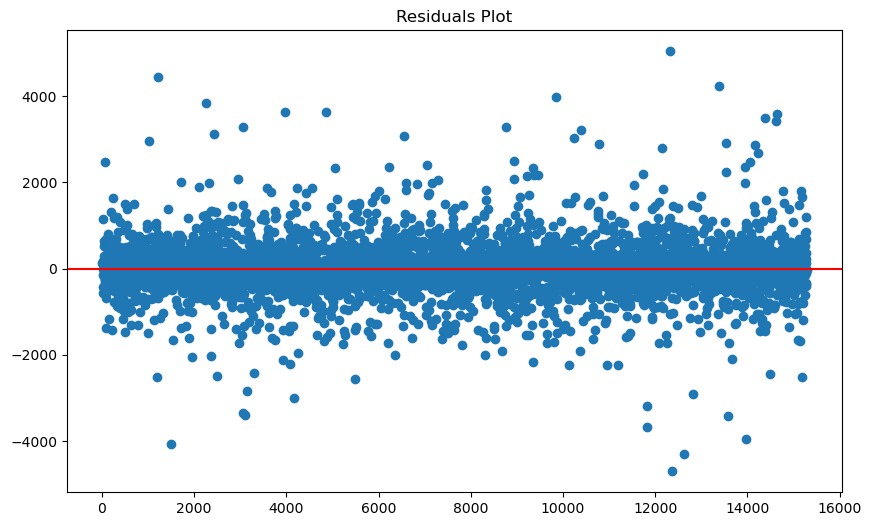

In [28]:
residuals = y_test - y_pred
plt.figure(figsize=(10,6))
plt.plot(residuals, marker='o', linestyle='')
plt.axhline(y=0, color='r')
plt.title("Residuals Plot")
plt.show()


X = train_data.drop(['yield','Cluster'], axis=1)
y = train_data['yield']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=15
)

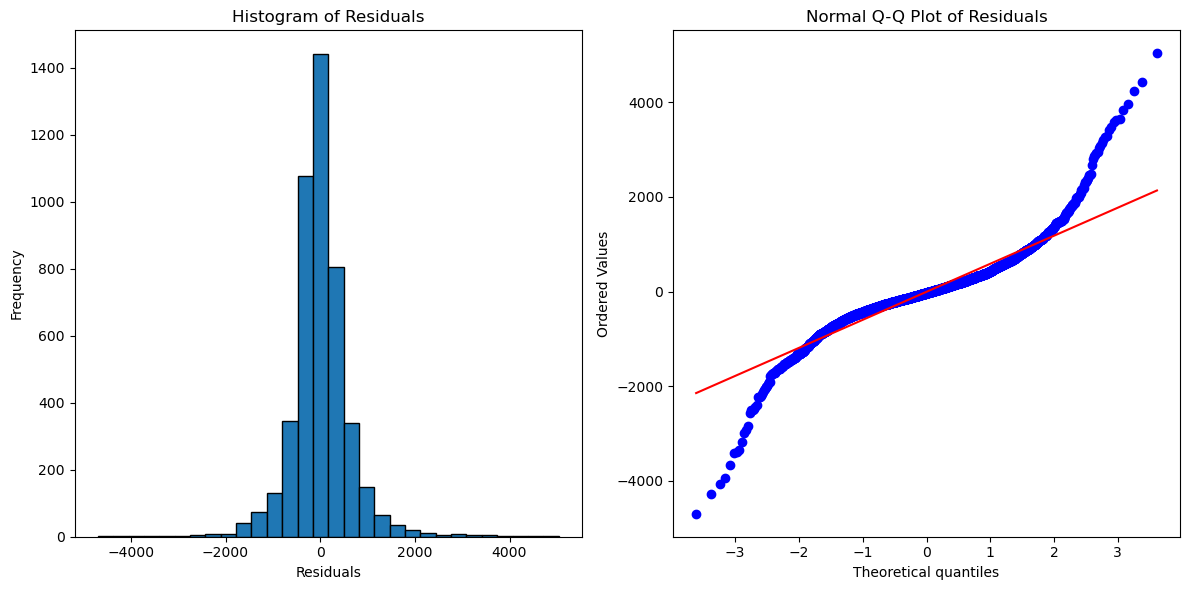

In [33]:
# 绘制残差的直方图
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# 绘制残差的Q-Q图
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

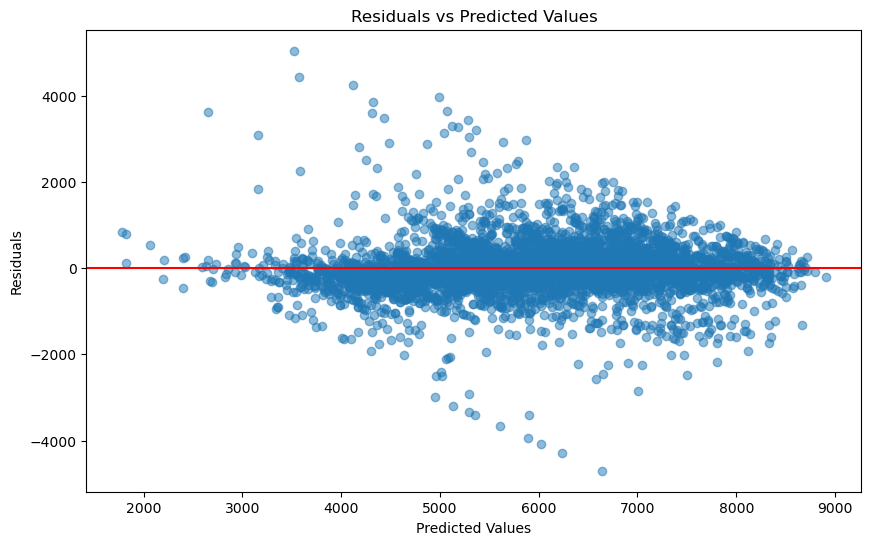

In [34]:
# 绘制残差与预测值的散点图以检查同方差性
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.axhline(y=0, color='r', linestyle='-')
plt.show()

In [37]:
# 使用与训练模型时相同数量的主成分进行预测
x_test_scaled = scaler.transform(test_data.drop(columns=['predicted_yield'], errors='ignore'))
x_test_pca = pca.transform(x_test_scaled)
x_test_pca_reduced = x_test_pca[:, :n_components]

# 使用模型进行预测  ↓↓↓ 这里改成 reg_model
test_predictions = reg_model.predict(x_test_pca_reduced)
test_data_with_predictions = test_data.copy()
test_data_with_predictions['predicted_yield'] = test_predictions
test_data_with_predictions.head()

,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,predicted_yield
0,25.0,0.25,0.25,0.25,0.25,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.399367,0.408088,31.394569,4403.677514
1,12.5,0.25,0.25,0.75,0.63,94.6,57.2,79.0,68.2,33.0,55.9,1.0,0.10,0.488048,0.442866,36.846956,6141.142129
2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.583379,0.487057,40.037644,7279.014537
3,25.0,0.50,0.38,0.38,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.433014,0.422847,33.116091,5133.609279
4,37.5,0.75,0.25,0.25,0.25,94.6,57.2,79.0,68.2,33.0,55.9,24.0,0.39,0.360996,0.388860,29.558019,3598.218257


In [29]:
rf = RandomForestRegressor(random_state=15)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"随机森林(初始) MSE: {mean_squared_error(y_test,y_pred_rf):.2f}, R2: {r2_score(y_test,y_pred_rf):.4f}")


随机森林(初始) MSE: 345234.69, R2: 0.8132


In [32]:
# 特征重要性
importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("特征重要性：\n", importances_df)

# ====================== 8. 测试集预测（随机森林） ======================
test_pred = rf.predict(test_data)
test_data['predicted_yield'] = test_pred
print("测试集预测结果：\n", test_data.head())

特征重要性：
                  Feature  Importance
13              fruitset    0.754544
15                 seeds    0.142669
14             fruitmass    0.040586
3                andrena    0.010986
4                  osmia    0.009662
11           RainingDays    0.007136
12    AverageRainingDays    0.006667
2                bumbles    0.004934
1               honeybee    0.004236
0              clonesize    0.003677
9       MinOfLowerTRange    0.002650
7   AverageOfUpperTRange    0.002506
10  AverageOfLowerTRange    0.002499
6       MinOfUpperTRange    0.002448
5       MaxOfUpperTRange    0.002411
8       MaxOfLowerTRange    0.002389
测试集预测结果：
    clonesize  honeybee  bumbles  andrena  osmia  MaxOfUpperTRange  \
0       25.0      0.25     0.25     0.25   0.25              86.0   
1       12.5      0.25     0.25     0.75   0.63              94.6   
2       12.5      0.25     0.25     0.63   0.63              86.0   
3       25.0      0.50     0.38     0.38   0.63              86.0   
4       

In [43]:
# 1. 导入所有需要的库
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ==============================================
# 2. 【必须加这一步】拆分训练集和测试集
# ==============================================
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. 定义模型 & 随机搜索
model = RandomForestRegressor(random_state=42)
param_dist = {
    "n_estimators": np.arange(50, 200, 10),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_depth": [None, 10, 20, 30]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    random_state=42
)

# 4. 训练
random_search.fit(x_train, y_train)

# 5. 获取最优参数
best_params = random_search.best_params_
print("最佳参数:", best_params)

# 6. 使用最优参数训练最终模型
best_rf_model = RandomForestRegressor(**best_params, random_state=15)
best_rf_model.fit(x_train, y_train)

# 7. 预测 & 评估
y_pred = best_rf_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

最佳参数: {'n_estimators': 90, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}
Mean Squared Error (MSE): 315677.1799701833
R-squared (R2): 0.8204273494848066


In [44]:
# 获取特征重要性
feature_importances = best_rf_model.feature_importances_

# 创建特征重要性的DataFrame
features = x_train.columns
importances_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# 按重要性排序
importances_df.sort_values(by='Importance', ascending=False, inplace=True)

importances_df

,Feature,Importance
13,fruitset,0.831908
15,seeds,0.130862
14,fruitmass,0.015150
3,andrena,0.002874
11,RainingDays,0.002808
12,AverageRainingDays,0.002776
4,osmia,0.002745
8,MaxOfLowerTRange,0.001597
1,honeybee,0.001444
7,AverageOfUpperTRange,0.001214
